In [11]:
import warnings
warnings.filterwarnings("ignore")


# Linear Regression and Statistics

# Linear Regression

## 1. Linear Additive Model

$$
Y = \beta_0 + \beta_1X_1 + \cdots + \beta_pX_p + \epsilon
$$

- $\mathbf{X} = (X_1, \ldots, X_p)$: input/features.
- $\boldsymbol{\beta} = (\beta_0, \ldots, \beta_p)^T$: true coefficients.
- $\epsilon$: random noise.

> **Important:** $\boldsymbol{\beta}$ is fixed but unknown.

---

## 2. True vs Estimated Coefficients

$$
\boldsymbol{\beta} \neq \hat{\boldsymbol{\beta}}
$$

- $\boldsymbol{\beta}$ = true coefficients used to generate the data.
- $\hat{\boldsymbol{\beta}}$ = coefficients estimated from training data.

> **Hat ($\hat{}$) = estimated from data.**

---

## 3. Prediction

For a new input $\mathbf{x}$:

$$
\hat{y}
=
\hat{\beta}_0
+
\hat{\beta}_1x_1
+\cdots+
\hat{\beta}_px_p
$$

---

## 4. Residual

$$
e_i = y_i - \hat{y}_i
$$

> **Residual = Actual value − Predicted value**

---

## 5. Residual Sum of Squares (RSS)

$$
RSS
=
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Linear regression finds the coefficients that minimize RSS:

$$
\hat{\boldsymbol{\beta}}
=
\arg\min_{\boldsymbol{\theta}}
\sum_{i=1}^{n}
\left(
y_i-f_L(\mathbf{x}_i;\boldsymbol{\theta})
\right)^2
$$

- $\boldsymbol{\theta}$ = candidate/temporary coefficients.
- The best $\boldsymbol{\theta}$ becomes $\hat{\boldsymbol{\beta}}$.

---

## 6. Matrix Form

$$
RSS
=
\left\|
\mathbf{y}
-
\mathbf{M}_X\boldsymbol{\theta}
\right\|^2
$$

$$
\mathbf{y}
=
\begin{bmatrix}
y_1\\
\vdots\\
y_n
\end{bmatrix}
$$

$$
\mathbf{M}_X
=
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1p}\\
\vdots & \vdots & & \vdots\\
1 & x_{n1} & \cdots & x_{np}
\end{bmatrix}
$$

> **Important:** The first column of $1$s represents the intercept $\beta_0$.

---

## 7. Linear Regression Solution

$$
\hat{\boldsymbol{\beta}}
=
(\mathbf{M}_X^T\mathbf{M}_X)^{-1}
\mathbf{M}_X^T\mathbf{y}
$$

---

## 8. Simple Linear Regression ($p=1$)

$$
\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1X
$$

- $\hat{\beta}_0$ = intercept
- $\hat{\beta}_1$ = slope

$$
\hat{\beta}_1
=
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sum_{i=1}^{n}(x_i-\bar{x})^2
}
$$

$$
\hat{\beta}_0
=
\bar{y}-\hat{\beta}_1\bar{x}
$$

---

## Main Idea

$$
\boxed{
\text{Linear Regression finds coefficients that minimize squared prediction errors.}
}
$$

$$
\text{Actual} - \text{Predicted}
=
\text{Residual}
$$

$$
RSS
=
\sum (\text{Residual})^2
$$

# Coefficient Uncertainty

## 1. Estimated Coefficients Are Random

In linear regression:

$$
\mathbf{y} = M_X\boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

we estimate the coefficients using:

$$
\hat{\boldsymbol{\beta}}
=
(M_X^T M_X)^{-1}M_X^T\mathbf{y}
$$

Because the data $X$ and $Y$ are random, the estimated coefficients $\hat{\boldsymbol{\beta}}$ are also **random variables**.

> Different training datasets → different estimated coefficients.

---

## 2. Unbiased Estimator

A key result is:

$$
\boxed{E[\hat{\beta}_i] = \beta_i}
$$

So, on average, the estimated coefficient equals the true coefficient.

This is called an **unbiased estimator**.

---

## 3. Coefficient Uncertainty

Since $\hat{\boldsymbol{\beta}}$ is random, we can measure how much it varies using its covariance matrix:

$$
\boxed{
\operatorname{Cov}(\hat{\boldsymbol{\beta}})
=
\sigma^2(M_X^T M_X)^{-1}
}
$$

The diagonal elements give the variance of each coefficient:

$$
\boxed{
\operatorname{Var}(\hat{\beta}_i)
}
$$

The standard deviation is:

$$
\boxed{
\operatorname{SE}(\hat{\beta}_i)
=
\sqrt{\operatorname{Var}(\hat{\beta}_i)}
}
$$

The **standard error** tells us how uncertain our coefficient estimate is.

---

## 4. Simple Linear Regression

For:

$$
Y_i = \beta_0 + \beta_1X_i + \epsilon_i
$$

the slope estimate has variance:

$$
\boxed{
\operatorname{Var}(\hat{\beta}_1)
=
\frac{\sigma^2}
{\sum_{i=1}^{N}(X_i-\bar X)^2}
}
$$

Therefore:

$$
\operatorname{SE}(\hat{\beta}_1)
=
\frac{\sigma}
{\sqrt{\sum_{i=1}^{N}(X_i-\bar X)^2}}
$$

### Intuition

* More noise $\sigma$ → **more uncertainty**
* More observations/information in $X$ → **less uncertainty**
* More spread in $X$ → **less uncertainty in the slope**

---

## 5. Sampling Distribution of $\hat{\beta}_1$

Imagine repeatedly collecting training datasets and calculating $\hat{\beta}_1$ each time.

We would get:

$$
\hat{\beta}_1^{(1)},\hat{\beta}_1^{(2)},\ldots,\hat{\beta}_1^{(K)}
$$

These estimates form a **sampling distribution**.

For the example in the lecture:

$$
\beta_1 = 0.5
$$

and the estimates are approximately:

$$
\hat{\beta}_1 \sim N(0.5,\,0.05^2)
$$

So:

* **Center** $\approx 0.5$ → true coefficient
* **Spread** $\approx 0.05$ → standard error / uncertainty

### Key Idea

$$
\boxed{
\text{Different datasets}
\rightarrow
\text{different }\hat{\beta}
\rightarrow
\text{sampling distribution}
\rightarrow
\text{coefficient uncertainty}
}
$$


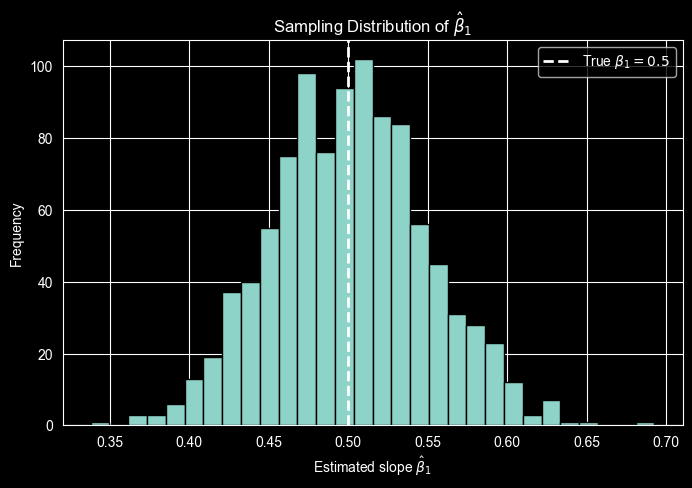

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Example from the lecture
true_beta1 = 0.5
se = 0.05

# Simulate 1,000 possible estimates of beta_1
np.random.seed(42)
beta1_hat = np.random.normal(true_beta1, se, 1000)

plt.figure(figsize=(8, 5))
plt.hist(beta1_hat, bins=30, edgecolor="black")

plt.axvline(true_beta1, linestyle="--", linewidth=2,
            label=r"True $\beta_1 = 0.5$")

plt.xlabel(r"Estimated slope $\hat{\beta}_1$")
plt.ylabel("Frequency")
plt.title(r"Sampling Distribution of $\hat{\beta}_1$")
plt.legend()
plt.show()

# Confidence Intervals for Linear Regression Coefficients

## 1. Distribution of $\hat{\beta}_1$

Recall that $\hat{\beta}_1$ is an **estimate** of the true regression coefficient $\beta_1$.

If we repeatedly:
1. Generate a new dataset from the same population
2. Fit the regression model
3. Calculate $\hat{\beta}_1$

then the different values of $\hat{\beta}_1$ form a **sampling distribution**.

For sufficiently appropriate conditions, this distribution is approximately normal:

$$
\hat{\beta}_1 \approx N\left(\beta_1,\operatorname{Var}(\hat{\beta}_1)\right)
$$

### Important properties

The sampling distribution has:

**Mean:**

$$
E[\hat{\beta}_1] = \beta_1
$$

This means $\hat{\beta}_1$ is an **unbiased estimator** of $\beta_1$.

**Standard deviation:**

$$
SE(\hat{\beta}_1)=\sqrt{\operatorname{Var}(\hat{\beta}_1)}
$$

The standard deviation of an estimator's sampling distribution is called its **standard error (SE)**.

---

## 2. The 95% Rule for a Normal Distribution

For a normal random variable:

$$
X \sim N(\mu,\sigma^2)
$$

approximately 95% of the probability lies within two standard deviations of the mean:

$$
P(\mu-2\sigma \leq X \leq \mu+2\sigma)\approx0.95
$$

### Intuition

Think of the sampling distribution as a bell curve:

- Center = $\mu$
- Spread = $\sigma$
- About 95% of observations fall within $\mu \pm 2\sigma$

---

## 3. Apply This to $\hat{\beta}_1$

Since $\hat{\beta}_1$ is approximately normal:

$$
P\left(
\beta_1-2SE(\hat{\beta}_1)
\leq
\hat{\beta}_1
\leq
\beta_1+2SE(\hat{\beta}_1)
\right)
\approx0.95
$$

Now rearrange the inequalities so that the **unknown $\beta_1$ is in the middle**:

$$
P\left(
\hat{\beta}_1-2SE(\hat{\beta}_1)
\leq
\beta_1
\leq
\hat{\beta}_1+2SE(\hat{\beta}_1)
\right)
\approx0.95
$$

Therefore, the 95% confidence interval is approximately:

$$
\boxed{
\hat{\beta}_1
\pm
2SE(\hat{\beta}_1)
}
$$

or explicitly:

$$
\boxed{
\left[
\hat{\beta}_1-2SE(\hat{\beta}_1),
\hat{\beta}_1+2SE(\hat{\beta}_1)
\right]
}
$$

### The key idea

We **cannot directly calculate $\beta_1$** because it is the unknown population parameter.

Instead, we calculate:

- $\hat{\beta}_1$ from our data
- $SE(\hat{\beta}_1)$ from our data

and use them to construct an interval that gives us information about the unknown $\beta_1$.

---

## 4. What Does "95% Confidence" Mean?

A confidence interval is about the **procedure**, not the probability that a particular fixed $\beta_1$ is inside the interval.

The correct intuition is:

> If we repeatedly collected new datasets and constructed a 95% confidence interval each time, approximately 95% of those intervals would contain the true $\beta_1$.

Once we have calculated one particular interval, $\beta_1$ is fixed—it either is or is not inside that interval.

### Example

Suppose:

$$
\hat{\beta}_1 = 0.50
$$

and

$$
SE(\hat{\beta}_1)=0.05
$$

Then:

$$
95\%~CI
\approx
0.50\pm2(0.05)
$$

$$
=\left[0.40,0.60\right]
$$

So the estimated coefficient is **0.50**, and the plausible range produced by this confidence-interval procedure is **0.40 to 0.60**.

---

## 5. Confidence Interval for $\beta_0$

The exact same logic applies to the intercept.

The approximate 95% confidence interval is:

$$
\boxed{
\hat{\beta}_0
\pm
2SE(\hat{\beta}_0)
}
$$

or:

$$
\left[
\hat{\beta}_0-2SE(\hat{\beta}_0),
\hat{\beta}_0+2SE(\hat{\beta}_0)
\right]
$$

So both regression coefficients can have confidence intervals:

$$
\hat{\beta}_0 \pm 2SE(\hat{\beta}_0)
$$

$$
\hat{\beta}_1 \pm 2SE(\hat{\beta}_1)
$$

---

## 6. Why Does the Standard Error Matter?

The standard error measures how much an estimated coefficient would vary across different samples.

### Small standard error

$$
SE(\hat{\beta}_1)\downarrow
\quad\Rightarrow\quad
\text{narrower confidence interval}
$$

This means our estimate is more precise.

### Large standard error

$$
SE(\hat{\beta}_1)\uparrow
\quad\Rightarrow\quad
\text{wider confidence interval}
$$

This means our estimate is less precise.

### Visual intuition

$$
\text{Confidence Interval}
=
\text{Estimate}
\pm
\text{Margin of Error}
$$

where approximately:

$$
\text{Margin of Error}=2SE
$$

---

## 7. Connection to Hypothesis Testing

Confidence intervals are closely connected to hypothesis tests.

For example, suppose we want to test:

$$
H_0:\beta_1=0
$$

If a 95% confidence interval for $\beta_1$ **does not contain 0**, this provides evidence against $H_0$ at approximately the 5% significance level.

If the interval **does contain 0**, the data are consistent with $\beta_1=0$ at that significance level.

This gives a useful connection:

$$
\boxed{
\text{Estimate}
\rightarrow
\text{Standard Error}
\rightarrow
\text{Confidence Interval}
\rightarrow
\text{Hypothesis Test}
}
$$

---

## 8. Important Assumptions / Warnings

The confidence interval derivation depends on assumptions.

### 1. Approximate normality

We assumed:

$$
\hat{\beta}_1 \approx N(\beta_1,\operatorname{Var}(\hat{\beta}_1))
$$

This approximation may not be appropriate in every situation.

### 2. Knowing $\sigma^2$

The derivation initially assumes that the measurement-noise variance

$$
\sigma^2
$$

is known.

In practice, $\sigma^2$ is usually **unknown**, but we can estimate it from the data. Later methods account for this.

---

## Formulas to Know

### Understand conceptually

$$
E[\hat{\beta}_1]=\beta_1
$$

The estimator is centered around the true coefficient.

$$
SE(\hat{\beta}_1)=\sqrt{\operatorname{Var}(\hat{\beta}_1)}
$$

The standard error measures the sampling variability of the coefficient estimate.

### Probably memorize

$$
\boxed{
95\%~CI
\approx
\hat{\beta}_1\pm2SE(\hat{\beta}_1)
}
$$

and similarly:

$$
\boxed{
95\%~CI
\approx
\hat{\beta}_0\pm2SE(\hat{\beta}_0)
}
$$

### Mainly theory

The derivation:

$$
P\left(
\beta_1-2SE
\leq
\hat{\beta}_1
\leq
\beta_1+2SE
\right)\approx0.95
$$

is useful for understanding **where the confidence interval comes from**, but you generally don't need to memorize the derivation.

---

## Key Takeaways

1. $\hat{\beta}_1$ varies from sample to sample, creating a **sampling distribution**.
2. The sampling distribution of $\hat{\beta}_1$ is approximately normal under appropriate assumptions and is centered at $\beta_1$.
3. The **standard error** measures the variability of $\hat{\beta}_1$ across samples.
4. A 95% confidence interval is approximately:
   $$
   \hat{\beta}_1\pm2SE(\hat{\beta}_1)
   $$
5. A 95% CI describes a procedure that captures the true parameter in about 95% of repeated samples.
6. Confidence intervals and hypothesis tests are closely connected: whether a CI contains a hypothesized value such as $0$ can tell us about the corresponding hypothesis test.

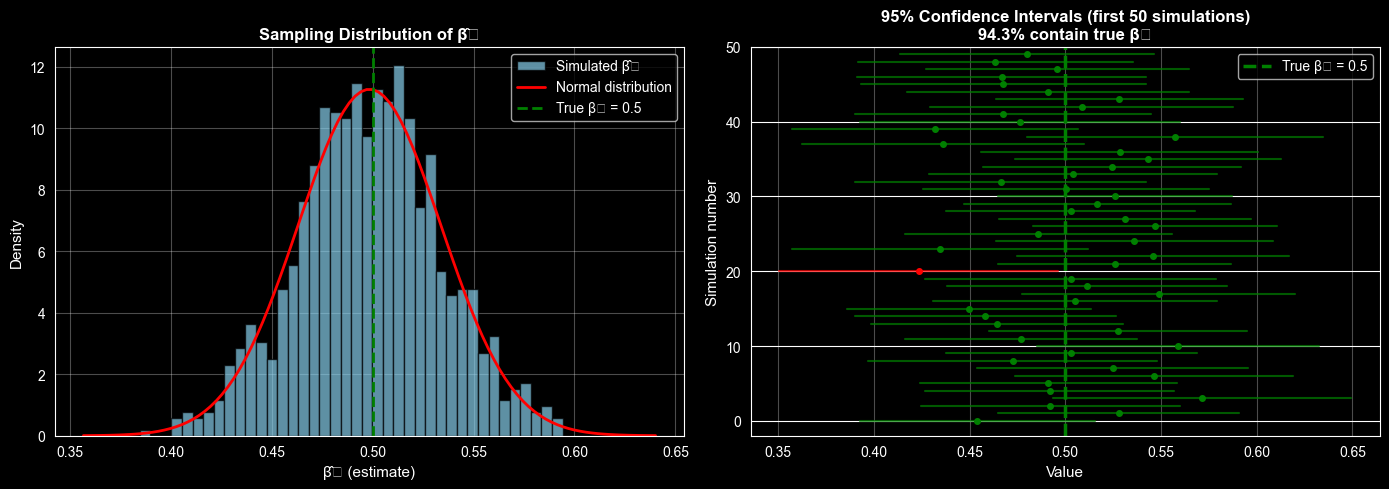


Out of 1000 simulations:
  943 confidence intervals contained the true β₁ (94.3%)
  57 did not (5.7%)

What this visualization teaches you:

Left plot: Shows that β̂₁ follows an approximately normal distribution. The more simulations you run, the more this histogram matches the red normal curve.
Right plot: Shows that ~95% of confidence intervals (green lines) capture the true β₁ (the dashed line), while ~5% miss it (red lines). This is exactly what "95% confidence" means.



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Simulate data and compute confidence intervals
n_simulations = 1000
n_samples = 100
true_beta_1 = 0.5
true_beta_0 = 2.0
sigma = 1.0

beta_1_estimates = []
ci_lower = []
ci_upper = []

for _ in range(n_simulations):
    # Generate synthetic data
    X = np.random.uniform(0, 10, n_samples)
    y = true_beta_0 + true_beta_1 * X + np.random.normal(0, sigma, n_samples)

    # Compute regression coefficients
    X_with_intercept = np.column_stack([np.ones(n_samples), X])
    beta_hat = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
    beta_1_hat = beta_hat[1]

    # Compute standard error of beta_1
    y_pred = X_with_intercept @ beta_hat
    residuals = y - y_pred
    sigma_hat_sq = np.sum(residuals**2) / (n_samples - 2)
    var_beta_1 = sigma_hat_sq / np.sum((X - X.mean())**2)
    se_beta_1 = np.sqrt(var_beta_1)

    # Compute 95% confidence interval
    margin_of_error = 2 * se_beta_1

    beta_1_estimates.append(beta_1_hat)
    ci_lower.append(beta_1_hat - margin_of_error)
    ci_upper.append(beta_1_hat + margin_of_error)

beta_1_estimates = np.array(beta_1_estimates)
ci_lower = np.array(ci_lower)
ci_upper = np.array(ci_upper)

# Count how many CIs contain the true value
contains_true = np.sum((ci_lower <= true_beta_1) & (ci_upper >= true_beta_1))
percentage = (contains_true / n_simulations) * 100

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram of β̂₁ estimates with normal overlay
ax1 = axes[0]
ax1.hist(beta_1_estimates, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Simulated β̂₁')

# Overlay theoretical normal distribution
mu = np.mean(beta_1_estimates)
sigma_est = np.std(beta_1_estimates)
x_range = np.linspace(mu - 4*sigma_est, mu + 4*sigma_est, 100)
ax1.plot(x_range, stats.norm.pdf(x_range, mu, sigma_est), 'r-', linewidth=2, label='Normal distribution')
ax1.axvline(true_beta_1, color='green', linestyle='--', linewidth=2, label=f'True β₁ = {true_beta_1}')
ax1.set_xlabel('β̂₁ (estimate)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Sampling Distribution of β̂₁', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Right plot: Sample of confidence intervals
ax2 = axes[1]
n_to_plot = 50  # Plot only first 50 CIs for clarity
colors = ['green' if ci_lower[i] <= true_beta_1 <= ci_upper[i] else 'red'
          for i in range(n_to_plot)]

for i in range(n_to_plot):
    ax2.plot([ci_lower[i], ci_upper[i]], [i, i], color=colors[i], linewidth=1.5, alpha=0.7)
    ax2.plot(beta_1_estimates[i], i, 'o', color=colors[i], markersize=4)

ax2.axvline(true_beta_1, color='green', linestyle='--', linewidth=2.5, label=f'True β₁ = {true_beta_1}')
ax2.set_xlabel('Value', fontsize=11)
ax2.set_ylabel('Simulation number', fontsize=11)
ax2.set_title(f'95% Confidence Intervals (first 50 simulations)\n{percentage:.1f}% contain true β₁',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, axis='x')
ax2.set_ylim(-2, n_to_plot)

plt.tight_layout()
plt.show()

print(f"\nOut of {n_simulations} simulations:")
print(f"  {contains_true} confidence intervals contained the true β₁ ({percentage:.1f}%)")
print(f"  {n_simulations - contains_true} did not ({100 - percentage:.1f}%)")

print("""
What this visualization teaches you:

Left plot: Shows that β̂₁ follows an approximately normal distribution. The more simulations you run, the more this histogram matches the red normal curve.
Right plot: Shows that ~95% of confidence intervals (green lines) capture the true β₁ (the dashed line), while ~5% miss it (red lines). This is exactly what "95% confidence" means.
""")

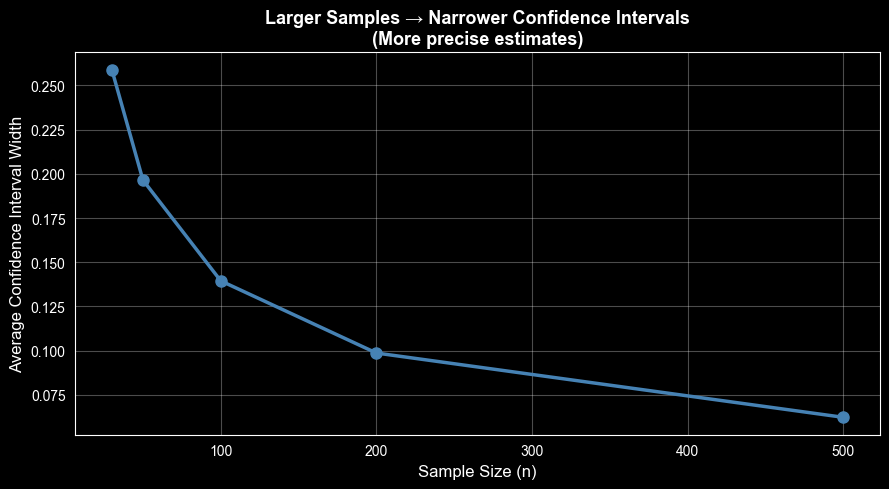

As sample size increases, the CI width decreases:
  n =  30: avg CI width = 0.2590
  n =  50: avg CI width = 0.1965
  n = 100: avg CI width = 0.1394
  n = 200: avg CI width = 0.0986
  n = 500: avg CI width = 0.0622

What this visualization teaches you:

As your sample size grows, your estimates become more precise (narrower confidence intervals)
This is because larger samples give you more information about the relationship between X and y
The relationship is roughly proportional to 1/√n (standard statistical result)



In [14]:
# Explore how sample size affects the width of confidence intervals

sample_sizes = np.array([30, 50, 100, 200, 500])
mean_ci_widths = []

for n in sample_sizes:
    widths = []

    for _ in range(100):  # 100 simulations per sample size
        X = np.random.uniform(0, 10, n)
        y = true_beta_0 + true_beta_1 * X + np.random.normal(0, sigma, n)

        X_with_intercept = np.column_stack([np.ones(n), X])
        beta_hat = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
        beta_1_hat = beta_hat[1]

        y_pred = X_with_intercept @ beta_hat
        residuals = y - y_pred
        sigma_hat_sq = np.sum(residuals**2) / (n - 2)
        var_beta_1 = sigma_hat_sq / np.sum((X - X.mean())**2)
        se_beta_1 = np.sqrt(var_beta_1)

        margin_of_error = 2 * se_beta_1
        width = 2 * margin_of_error
        widths.append(width)

    mean_ci_widths.append(np.mean(widths))

# Plot
plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, mean_ci_widths, 'o-', linewidth=2.5, markersize=8, color='steelblue')
plt.xlabel('Sample Size (n)', fontsize=12)
plt.ylabel('Average Confidence Interval Width', fontsize=12)
plt.title('Larger Samples → Narrower Confidence Intervals\n(More precise estimates)',
          fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("As sample size increases, the CI width decreases:")
for n, width in zip(sample_sizes, mean_ci_widths):
    print(f"  n = {n:3d}: avg CI width = {width:.4f}")

print("""
What this visualization teaches you:

As your sample size grows, your estimates become more precise (narrower confidence intervals)
This is because larger samples give you more information about the relationship between X and y
The relationship is roughly proportional to 1/√n (standard statistical result)
""")

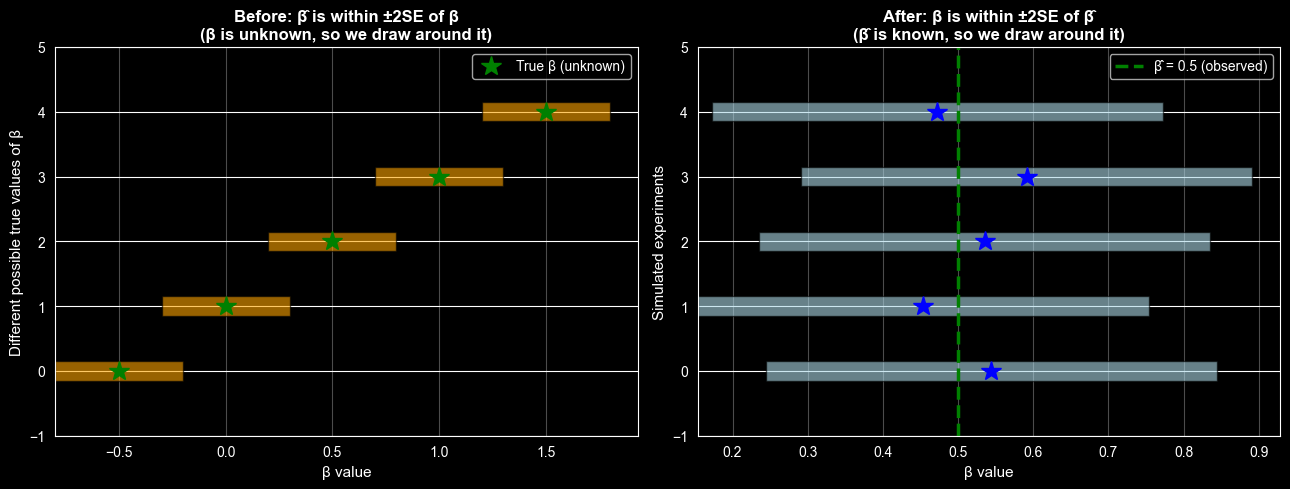

The FLIP:
  BEFORE: P(β - 2SE ≤ β̂ ≤ β + 2SE) = 0.95
          → β̂ lands inside an interval around the true β

  AFTER:  P(β̂ - 2SE ≤ β ≤ β̂ + 2SE) = 0.95
          → β lands inside an interval around our estimate β̂

This is why confidence intervals are 'centered' on our observed estimate!

What this visualization teaches you:

The flip shows why confidence intervals are constructed around β̂ (what we observe)
It transforms from "our estimate is near the truth" to "the truth is near our estimate"
This is the key insight that makes confidence intervals practical



In [16]:
# Illustrate the conceptual flip from "β̂ is near β" to "β is near β̂"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Original inequality (β̂ sandwiched around β - unknown β)
ax1 = axes[0]
beta_values = np.linspace(-0.5, 1.5, 5)
for i, beta_true in enumerate(beta_values):
    se = 0.15
    ax1.barh(i, 4*se, left=beta_true - 2*se, height=0.3, alpha=0.6, color='orange', edgecolor='black')
    ax1.plot(beta_true, i, 'g*', markersize=15, label='True β (unknown)' if i == 0 else '')

ax1.set_xlabel('β value', fontsize=11)
ax1.set_ylabel('Different possible true values of β', fontsize=11)
ax1.set_title('Before: β̂ is within ±2SE of β\n(β is unknown, so we draw around it)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='x')
ax1.set_ylim(-1, len(beta_values))

# RIGHT: After rearrangement (β sandwiched around β̂ - observed β̂)
ax2 = axes[1]
beta_hat_observed = 0.5  # Our actual estimate from data
se_observed = 0.15

# Show a few simulations
for i in range(5):
    noise = np.random.normal(0, se_observed/2)
    beta_hat = beta_hat_observed + noise
    ax2.barh(i, 4*se_observed, left=beta_hat - 2*se_observed, height=0.3, alpha=0.6, color='lightblue', edgecolor='black')
    ax2.plot(beta_hat, i, 'b*', markersize=15)

ax2.axvline(0.5, color='green', linestyle='--', linewidth=2.5, label='β̂ = 0.5 (observed)')
ax2.set_xlabel('β value', fontsize=11)
ax2.set_ylabel('Simulated experiments', fontsize=11)
ax2.set_title('After: β is within ±2SE of β̂\n(β̂ is known, so we draw around it)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='x')
ax2.set_ylim(-1, 5)

plt.tight_layout()
plt.show()

print("The FLIP:")
print("  BEFORE: P(β - 2SE ≤ β̂ ≤ β + 2SE) = 0.95")
print("          → β̂ lands inside an interval around the true β")
print("")
print("  AFTER:  P(β̂ - 2SE ≤ β ≤ β̂ + 2SE) = 0.95")
print("          → β lands inside an interval around our estimate β̂")
print("")
print("This is why confidence intervals are 'centered' on our observed estimate!")

print("""
What this visualization teaches you:

The flip shows why confidence intervals are constructed around β̂ (what we observe)
It transforms from "our estimate is near the truth" to "the truth is near our estimate"
This is the key insight that makes confidence intervals practical
""")

# Hypothesis Testing

## The Problem with Direct Checking

When we fit a linear model: $Y = \beta_0 + \beta_1 X_1 + \epsilon$

A natural question arises: **Does $X_1$ actually influence $Y$?**

A tempting but **wrong** approach: Estimate $\hat{\beta}_1$ and check if it equals exactly 0.

**Why this fails:** $\hat{\beta}_1$ is a continuous random variable. For any continuous distribution, the probability of observing any exact value (like 0) is **zero**.

Think of it like this: If human weights follow a normal distribution centered at 80 kg, what's the probability that a randomly chosen person weighs exactly 82.371817 kg? Zero—because there are infinitely many possible values. But you *can* ask: "What's the probability they weigh between 78–79 kg?" That has a positive probability (the area under the curve).

---

## The Hypothesis Framework

Instead, we set up a formal hypothesis test:

**Null Hypothesis ($H_0$):** $\beta_1 = 0$ (no relationship between $X_1$ and $Y$)

**Alternative Hypothesis ($H_a$):** $\beta_1 \neq 0$ (there is a relationship)

We then ask: **If $H_0$ is true, how likely is our observed $\hat{\beta}_1$?**

---

## The Confidence Interval Approach

**Key insight:** When $H_0$ is true ($\beta_1 = 0$), we know:

$$\hat{\beta}_1 \sim N\left(0, \text{SE}(\hat{\beta}_1)^2\right)$$

From the normal distribution, we know that 95% of the probability mass falls within $\pm 2$ standard deviations:

$$P\left(-2 \cdot \text{SE} \leq \hat{\beta}_1 \leq 2 \cdot \text{SE}\right) = 0.95$$

**Decision rule:**
- If $\hat{\beta}_1$ **falls inside** this interval: Consistent with $H_0$; we fail to reject it
- If $\hat{\beta}_1$ **falls outside** this interval: This would be a rare event if $H_0$ were true; we have strong evidence to reject $H_0$

---

## The t-Statistic (Equivalent but More General)

Instead of comparing $\hat{\beta}_1$ directly, we standardize it:

$$t_1 = \frac{\hat{\beta}_1}{\text{SE}(\hat{\beta}_1)}$$

**When $H_0$ is true:**
- Numerator: $\hat{\beta}_1 \sim N(0, \text{SE}(\hat{\beta}_1)^2)$, so $E[\hat{\beta}_1] = 0$
- Denominator: $\text{SE}(\hat{\beta}_1)$ is the standard deviation
- Result: $t_1 \sim N(0, 1)$ (standard normal)

**Decision rule:**
- If $|t_1| \leq 2$: Data is consistent with $H_0$; fail to reject
- If $|t_1| > 2$: Data provides strong evidence against $H_0$; reject it

This is equivalent to the confidence interval approach but more general (works for other distributions too).

---

## Important Conceptual Insight: The Legal Parable

Hypothesis testing is often misunderstood. Think of it like a criminal trial:

- **Null hypothesis:** The defendant is innocent
- **Alternative hypothesis:** The defendant is guilty

**If we reject $H_0$ (declare guilty):** There's *always* a small chance the person is actually innocent but convicted unfairly.

**If we fail to reject $H_0$ (declare not guilty):** This does NOT mean we've proven innocence. It just means there's insufficient evidence of guilt.

**Critical distinction:**
- We can provide evidence *against* $H_0$
- We can *never* provide evidence *for* $H_0$ using hypothesis testing
- Failing to reject $H_0$ ≠ accepting $H_0$

In practice, we often act "as if" $H_0$ is true when we fail to reject it, but this is a pragmatic choice, not a statistical proof.

---

## Model Accuracy Metrics

Once we've decided whether $\beta_1$ matters, we measure how well our model fits:

### Residual Sum of Squares (RSS)
$$\text{RSS} = \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2$$
Sum of squared errors after fitting the model.

### Total Sum of Squares (TSS)
$$\text{TSS} = \sum_{i=1}^n \left(y_i - \bar{y}\right)^2$$
Sum of squared errors if we used only the mean $\bar{y}$ (i.e., if $\beta_1 = 0$).

### R-squared ($R^2$)
$$R^2 = \frac{\text{TSS} - \text{RSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}}$$

**Interpretation:** Fraction of variance in $Y$ explained by $X_1$.
- $R^2 = 0$: $X_1$ explains none of the variance (model is useless)
- $R^2 = 1$: $X_1$ explains all the variance (perfect fit)
- $R^2 = 0.7$: $X_1$ explains 70% of the variance

### Residual Standard Error (RSE)
$$\text{RSE} = \sqrt{\frac{\text{RSS}}{n - p - 1}}$$

Estimates the standard deviation of the measurement noise $\epsilon$. Useful when true $\sigma$ is unknown.

---

## Key Takeaways

1. **The core problem:** We can't check if $\hat{\beta}_1 = 0$ exactly because it's a continuous random variable. Instead, we ask: "Is $\hat{\beta}_1$ consistent with $H_0$?"

2. **The framework:** Hypothesis testing uses a sampling distribution to quantify how rare our observation would be if $H_0$ were true.

3. **The t-statistic:** Standardizing $\hat{\beta}_1$ by its SE gives us a test statistic that follows $N(0,1)$ under $H_0$, making the decision rule simple: $|t| > 2$ suggests rejection.

4. **The legal parable matters:** Rejecting $H_0$ provides evidence *against* the null, but never proves the alternative. Failing to reject doesn't mean $H_0$ is true.

5. **$R^2$ measures fit quality:** After deciding if a variable matters, we use $R^2$ to quantify how much variance it explains—a practical summary of model usefulness.

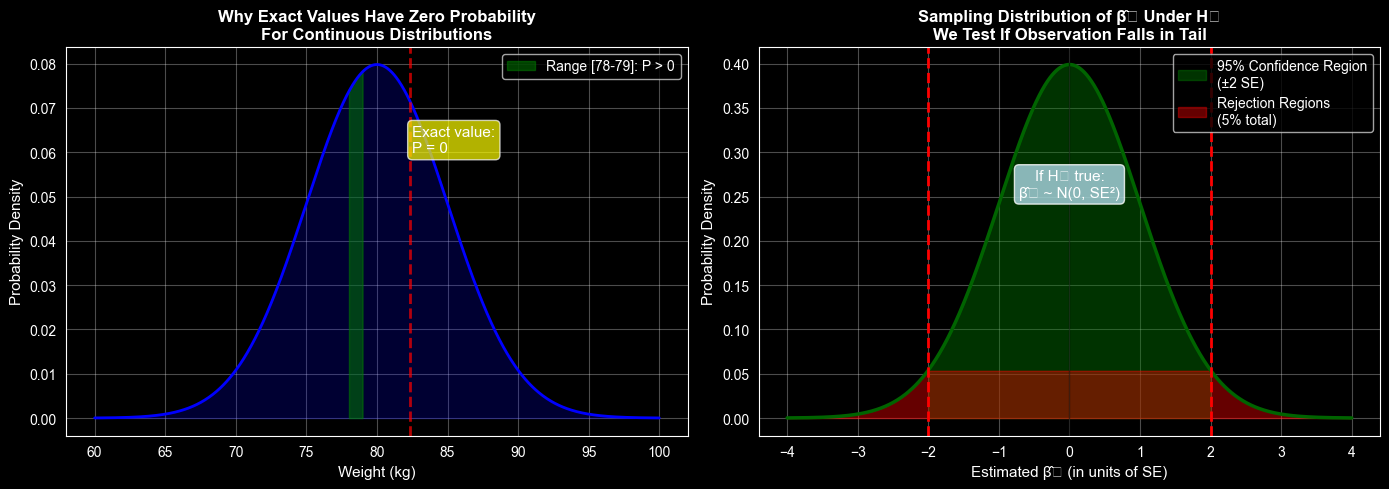

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Continuous distribution (weights)
x_weights = np.linspace(60, 100, 1000)
y_weights = norm.pdf(x_weights, loc=80, scale=5)
ax1.plot(x_weights, y_weights, 'b-', linewidth=2)
ax1.axvline(82.371817, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.fill_between(x_weights, 0, y_weights, alpha=0.2, color='blue')
ax1.text(82.5, 0.06, 'Exact value:\nP = 0', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax1.fill_between(x_weights[(x_weights >= 78) & (x_weights <= 79)],
                  0, y_weights[(x_weights >= 78) & (x_weights <= 79)],
                  alpha=0.5, color='green', label='Range [78-79]: P > 0')
ax1.set_xlabel('Weight (kg)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Why Exact Values Have Zero Probability\nFor Continuous Distributions', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Estimated β̂₁ under H₀
x_beta = np.linspace(-4, 4, 1000)
y_beta = norm.pdf(x_beta, loc=0, scale=1)
ax2.plot(x_beta, y_beta, 'darkgreen', linewidth=2.5)
ax2.fill_between(x_beta[(x_beta >= -2) & (x_beta <= 2)], 0, y_beta[(x_beta >= -2) & (x_beta <= 2)],
                  alpha=0.4, color='green', label='95% Confidence Region\n(±2 SE)')
ax2.fill_between(x_beta[(x_beta < -2) | (x_beta > 2)], 0, y_beta[(x_beta < -2) | (x_beta > 2)],
                  alpha=0.4, color='red', label='Rejection Regions\n(5% total)')
ax2.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axvline(2, color='red', linestyle='--', linewidth=2)
ax2.axvline(-2, color='red', linestyle='--', linewidth=2)
ax2.text(0, 0.25, 'If H₀ true:\nβ̂₁ ~ N(0, SE²)', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax2.set_xlabel('Estimated β̂₁ (in units of SE)', fontsize=11)
ax2.set_ylabel('Probability Density', fontsize=11)
ax2.set_title('Sampling Distribution of β̂₁ Under H₀\nWe Test If Observation Falls in Tail', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

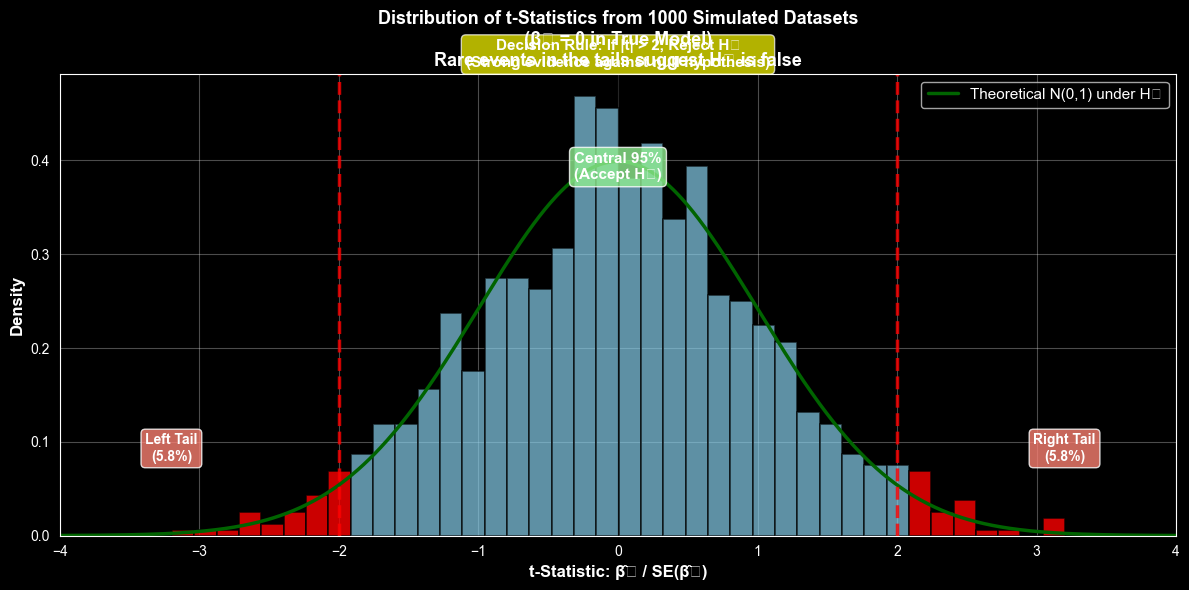

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Simulate 1000 datasets where β₁ = 0 (null hypothesis is TRUE)
np.random.seed(42)
n = 100  # sample size per dataset
n_simulations = 1000
t_statistics = []

for _ in range(n_simulations):
    # Generate X from normal distribution
    X = np.random.normal(0, 1, n)

    # Generate Y = β₀ + ε (β₁ = 0 under H₀)
    epsilon = np.random.normal(0, 1, n)
    Y = 5 + epsilon  # intercept = 5, but no effect of X

    # Fit linear regression
    X_with_intercept = np.column_stack([np.ones(n), X])
    beta_hat = np.linalg.lstsq(X_with_intercept, Y, rcond=None)[0]

    # Calculate residuals and SE
    residuals = Y - X_with_intercept @ beta_hat
    RSS = np.sum(residuals**2)
    residual_std_error = np.sqrt(RSS / (n - 2))

    # Compute SE of β̂₁
    XtX_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    se_beta1 = residual_std_error * np.sqrt(XtX_inv[1, 1])

    # Compute t-statistic
    t_stat = beta_hat[1] / se_beta1
    t_statistics.append(t_stat)

# Plot histogram of t-statistics
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
counts, bins, patches = ax.hist(t_statistics, bins=40, density=True, alpha=0.7,
                                color='skyblue', edgecolor='black', linewidth=1.2)

# Color rejection regions
for i, patch in enumerate(patches):
    if bins[i] < -2 or bins[i] > 2:
        patch.set_facecolor('red')
        patch.set_alpha(0.8)

# Overlay theoretical N(0,1) distribution
x_theory = np.linspace(-4, 4, 1000)
y_theory = norm.pdf(x_theory, 0, 1)
ax.plot(x_theory, y_theory, 'darkgreen', linewidth=2.5, label='Theoretical N(0,1) under H₀')

# Rejection lines and regions
ax.axvline(-2, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.axvline(2, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Annotations
rejection_count = sum(1 for t in t_statistics if abs(t) > 2)
ax.text(0, 0.38, f'Central 95%\n(Accept H₀)', fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), fontweight='bold')
ax.text(-3.2, 0.08, f'Left Tail\n({rejection_count/n_simulations*100:.1f}%)', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.8), fontweight='bold')
ax.text(3.2, 0.08, f'Right Tail\n({rejection_count/n_simulations*100:.1f}%)', fontsize=10, ha='center',
        bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.8), fontweight='bold')

# Decision rule text
ax.text(0, 0.50, 'Decision Rule: If |t| > 2, Reject H₀\n(Strong evidence against null hypothesis)',
        fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontweight='bold')

ax.set_xlabel('t-Statistic: β̂₁ / SE(β̂₁)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Distribution of t-Statistics from 1000 Simulated Datasets\n(β₁ = 0 in True Model)\nRare events in the tails suggest H₀ is false',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

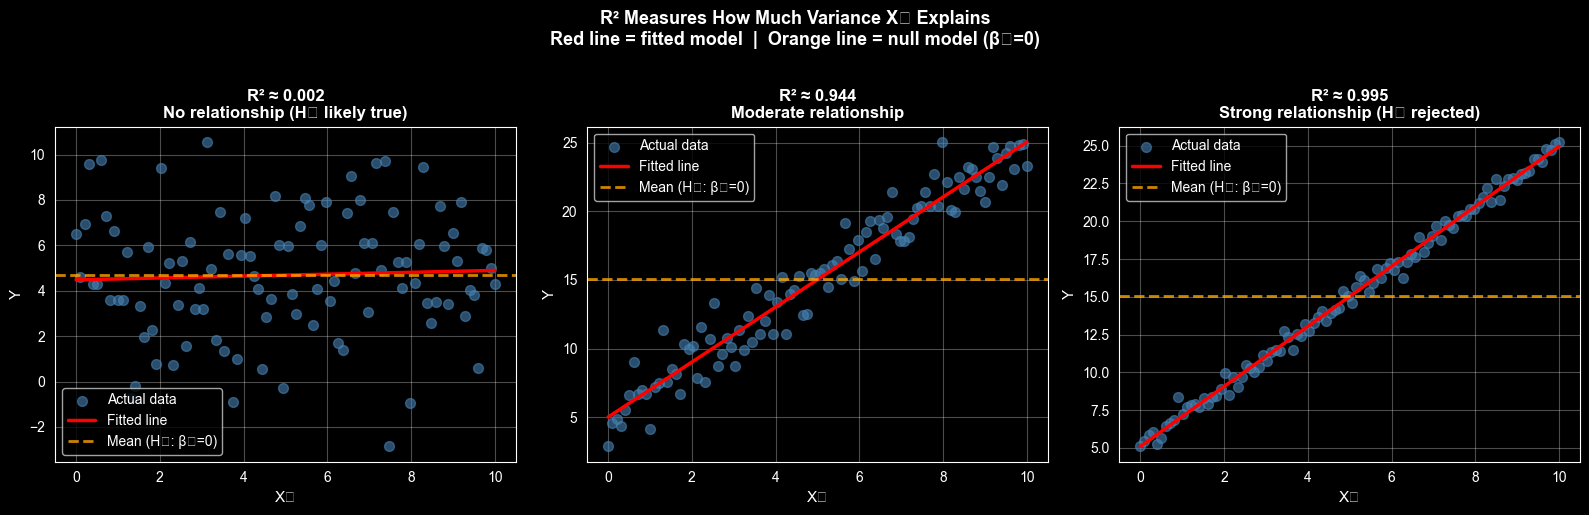

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)

# Case 1: R² ≈ 0 (no relationship)
epsilon1 = np.random.normal(0, 3, 100)
Y1 = 5 + epsilon1
model1 = LinearRegression().fit(X, Y1)
y_pred1 = model1.predict(X)
rss1 = np.sum((Y1 - y_pred1)**2)
tss1 = np.sum((Y1 - Y1.mean())**2)
r2_1 = 1 - rss1 / tss1

ax1 = axes[0]
ax1.scatter(X, Y1, alpha=0.6, s=50, color='steelblue', label='Actual data')
ax1.plot(X, y_pred1, 'r-', linewidth=2.5, label='Fitted line')
ax1.axhline(Y1.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.8, label='Mean (H₀: β₁=0)')
ax1.set_xlabel('X₁', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_title(f'R² ≈ {r2_1:.3f}\nNo relationship (H₀ likely true)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Case 2: R² ≈ 0.5 (moderate relationship)
beta_true = 2
epsilon2 = np.random.normal(0, 1.5, 100)
Y2 = 5 + beta_true * X.ravel() + epsilon2
model2 = LinearRegression().fit(X, Y2)
y_pred2 = model2.predict(X)
rss2 = np.sum((Y2 - y_pred2)**2)
tss2 = np.sum((Y2 - Y2.mean())**2)
r2_2 = 1 - rss2 / tss2

ax2 = axes[1]
ax2.scatter(X, Y2, alpha=0.6, s=50, color='steelblue', label='Actual data')
ax2.plot(X, y_pred2, 'r-', linewidth=2.5, label='Fitted line')
ax2.axhline(Y2.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.8, label='Mean (H₀: β₁=0)')
ax2.set_xlabel('X₁', fontsize=11)
ax2.set_ylabel('Y', fontsize=11)
ax2.set_title(f'R² ≈ {r2_2:.3f}\nModerate relationship', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Case 3: R² ≈ 0.95 (strong relationship)
epsilon3 = np.random.normal(0, 0.4, 100)
Y3 = 5 + beta_true * X.ravel() + epsilon3
model3 = LinearRegression().fit(X, Y3)
y_pred3 = model3.predict(X)
rss3 = np.sum((Y3 - y_pred3)**2)
tss3 = np.sum((Y3 - Y3.mean())**2)
r2_3 = 1 - rss3 / tss3

ax3 = axes[2]
ax3.scatter(X, Y3, alpha=0.6, s=50, color='steelblue', label='Actual data')
ax3.plot(X, y_pred3, 'r-', linewidth=2.5, label='Fitted line')
ax3.axhline(Y3.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.8, label='Mean (H₀: β₁=0)')
ax3.set_xlabel('X₁', fontsize=11)
ax3.set_ylabel('Y', fontsize=11)
ax3.set_title(f'R² ≈ {r2_3:.3f}\nStrong relationship (H₀ rejected)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

fig.suptitle('R² Measures How Much Variance X₁ Explains\nRed line = fitted model  |  Orange line = null model (β₁=0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()